# IDS с метками: Logistic Regression и CatBoost

    Полное воспроизводимое демо на **локальном KDD Cup 1999 10%**: данные → очистка → split →
    feature engineering → корреляционный отбор → обучение → CV → validation threshold → test → SHAP → joblib.

    `label=0` — normal, `label=1` — attack. `attack_type` — детализация истинной метки, **не вход модели**.
    KDD исторический: итоговые метрики описывают этот набор, а не качество IDS в современной сети.

## 0. Импорты и проверка единой среды

Откройте этот notebook непосредственно в **VS Code** (расширения Python и Jupyter).
Справа сверху: **Select Kernel → Python Environments → `.venv/bin/python`** из этого проекта.
Если окружение не отображается, используйте **Enter interpreter path** и укажите
`/Users/newuser/Documents/OTUS/2409/ids-ml-detection-lab/.venv/bin/python`.
Затем нажмите **Run All** для запуска с первой до последней ячейки.

Для командной строки: `source .venv/bin/activate`, затем `python ...`.
Первая ячейка проверяет, что notebook, CLI и зарегистрированное ядро используют одну `.venv`.
При повторной установке среды выполните `uv sync --frozen --all-groups` и
`uv run python scripts/setup_notebook_kernel.py`.

In [1]:
import importlib.metadata as metadata
import json
import platform
import subprocess
import sys
import time
import warnings
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from catboost import Pool
from IPython.display import display
from jupyter_client.kernelspec import KernelSpecManager
from scipy.stats import chi2_contingency
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

from dataset_builder.schema import CATEGORICAL_FEATURES
from ids_ml_lab.demo import (
    DERIVED,
    RAW_FEATURES,
    CorrelationSelector,
    NetworkFeatures,
    bootstrap_metrics,
    choose_threshold,
    demo_cv,
    evaluate,
    export_bundle,
    load_full_data,
    make_demo_pipeline,
    model_scores,
    threshold_table,
)

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
expected_python = ROOT / ".venv/bin/python"
assert Path(sys.prefix).resolve() == (ROOT / ".venv").resolve(), (
    f"Выберите ядро ids-ml-detection-lab: {sys.executable}"
)
cli = json.loads(
    subprocess.check_output(
        [
            str(expected_python),
            "-c",
            'import json,sys; print(json.dumps({"executable":sys.executable,"prefix":sys.prefix,"version":sys.version}))',
        ],
        text=True,
    )
)
assert Path(cli["prefix"]).resolve() == Path(sys.prefix).resolve()
assert Path(cli["executable"]).resolve() == Path(sys.executable).resolve()
kernel = KernelSpecManager().get_kernel_spec("ids-ml-detection-lab")
assert Path(kernel.argv[0]).resolve() == expected_python.resolve()
assert sys.version_info[:2] == (3, 12)
PACKAGES = [
    "numpy",
    "pandas",
    "scikit-learn",
    "catboost",
    "shap",
    "scipy",
    "joblib",
    "ipykernel",
    "jupyterlab",
    "nbclient",
]
versions = {p: metadata.version(p) for p in PACKAGES}
display(
    pd.Series(
        {
            "notebook_python": sys.executable,
            "cli_python": cli["executable"],
            "kernel_python": kernel.argv[0],
            "python": platform.python_version(),
        }
    )
)
display(pd.Series(versions, name="version").to_frame())
warnings.filterwarnings("error", category=ConvergenceWarning)
SEED, CORRELATION_THRESHOLD, MAX_FPR = 42, 0.90, 0.05
BOOTSTRAP_ITERATIONS, SHAP_ROWS = 300, 160
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
ISOLATION = False
KINDS = ["logreg", "catboost"]

notebook_python    /Users/newuser/Documents/OTUS/2409/ids-ml-dete...
cli_python         /Users/newuser/Documents/OTUS/2409/ids-ml-dete...
kernel_python      /Users/newuser/Documents/OTUS/2409/ids-ml-dete...
python                                                        3.12.7
dtype: object

,version
numpy,2.2.6
pandas,2.3.3
scikit-learn,1.9.1
catboost,1.2.10
shap,0.52.0
scipy,1.18.1
joblib,1.6.0
ipykernel,6.31.0
jupyterlab,4.6.4
nbclient,0.11.0


## 1. Все данные из `data`: исходник и подготовленные splits
    Исходник содержит 41 признак и `attack_type`; бинарный `label` выводится из типа события.
    Parquet-файлы — уже существующая сбалансированная подвыборка того же источника с 16 признаками.
    Читаем **все файлы данных**, проверяем SHA-256 исходника и Parquet по manifest.
    Основной эксперимент использует весь локальный исходник, без balanced sampling и ограничения 24 000 строк.

    Удаляем повторные векторы входных признаков до split. При противоречивом бинарном label
    исключаем весь такой вектор и явно считаем потери. Разные названия атак с одинаковыми признаками
    схлопываются до первого события: сегментные результаты относятся к сохранённым представителям.
    Все оставшиеся уникальные события участвуют в эксперименте.

In [2]:
raw, splits, prepared, manifest, audit = load_full_data(ROOT, seed=SEED)
display(pd.Series(audit, name="data_audit").to_frame())
display(
    pd.DataFrame(
        [
            {
                "file": f"data/prepared/{name}.parquet",
                "rows": len(frame),
                "columns": len(frame.columns),
                "attack_rate": frame.label.mean(),
            }
            for name, frame in prepared.items()
        ]
    )
)
display(
    pd.Series({k: manifest[k] for k in ["source", "selection", "seed", "target"]}).to_frame(
        "prepared_manifest"
    )
)
display(raw.head(8))

,data_audit
source_rows,494021
unique_feature_rows,145583
conflicting_label_rows,2
redundant_rows_removed,348436
source_sha256,8045aca0d84e70e622d1148d7df782496f6333bf6eb979...
seed,42


,file,rows,columns,attack_rate
0,data/prepared/train.parquet,14400,18,0.5
1,data/prepared/validation.parquet,4800,18,0.5
2,data/prepared/test.parquet,4800,18,0.5


,prepared_manifest
source,"UCI KDD Cup 1999, 10% subset"
selection,"deduplicated, balanced binary sample; 60/20/20..."
seed,42
target,"label (0=normal, 1=attack)"


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.00,0.0,0.0,0.0,0.0,normal,0
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.00,0.0,0.0,0.0,0.0,normal,0
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal,0
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal,0
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal,0
5,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal,0
6,0,tcp,http,SF,212,1940,0,0,0,0,...,1.0,0.0,1.00,0.04,0.0,0.0,0.0,0.0,normal,0
7,0,tcp,http,SF,159,4087,0,0,0,0,...,1.0,0.0,0.09,0.04,0.0,0.0,0.0,0.0,normal,0


## 2. Что есть что: словарь признаков и качество данных
    Одна строка — сетевое соединение. `duration` — секунды, `src_bytes/dst_bytes` — байты;
    `protocol_type`, `service`, `flag` — категории. `count/srv_count` — счётчики соединений за 2 секунды;
    семейство `dst_host_*` характеризует окно соединений к хосту назначения.
    `*_rate` — доли, бинарные индикаторы — 0/1, оставшиеся поля — счётчики событий соединения.
    Дат и временной последовательности здесь нет: split случайный стратифицированный, **не OOT**.

,feature,description,dtype,missing,unique
0,duration,"Длительность соединения, секунды",int64,0,2495
1,protocol_type,Транспортный протокол,object,0,3
2,service,Сетевой сервис назначения,object,0,66
3,flag,Статус соединения,object,0,11
4,src_bytes,Байты от источника к получателю,int64,0,3300
5,dst_bytes,Байты в обратном направлении,int64,0,10725
6,land,Совпадают адреса/порты источника и назначения,int64,0,2
7,wrong_fragment,Ошибочные фрагменты,int64,0,3
8,urgent,Срочные пакеты,int64,0,4
9,hot,Hot indicators,int64,0,22


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration,494021.0,NaN,NaN,NaN,47.979302,707.746472,0.0,0.0,0.0,0.0,58329.0
protocol_type,494021,3,icmp,283602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,494021,66,ecr_i,281400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flag,494021,11,SF,378440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_bytes,494021.0,NaN,NaN,NaN,3025.610296,988218.10105,0.0,45.0,520.0,1032.0,693375640.0
dst_bytes,494021.0,NaN,NaN,NaN,868.532425,33040.001252,0.0,0.0,0.0,0.0,5155468.0
land,494021.0,NaN,NaN,NaN,0.000045,0.006673,0.0,0.0,0.0,0.0,1.0
wrong_fragment,494021.0,NaN,NaN,NaN,0.006433,0.134805,0.0,0.0,0.0,0.0,3.0
urgent,494021.0,NaN,NaN,NaN,0.000014,0.00551,0.0,0.0,0.0,0.0,3.0
hot,494021.0,NaN,NaN,NaN,0.034519,0.782103,0.0,0.0,0.0,0.0,30.0


,rows
attack_type,
smurf,280790
neptune,107201
normal,97278
back,2203
satan,1589
ipsweep,1247
portsweep,1040
warezclient,1020
teardrop,979


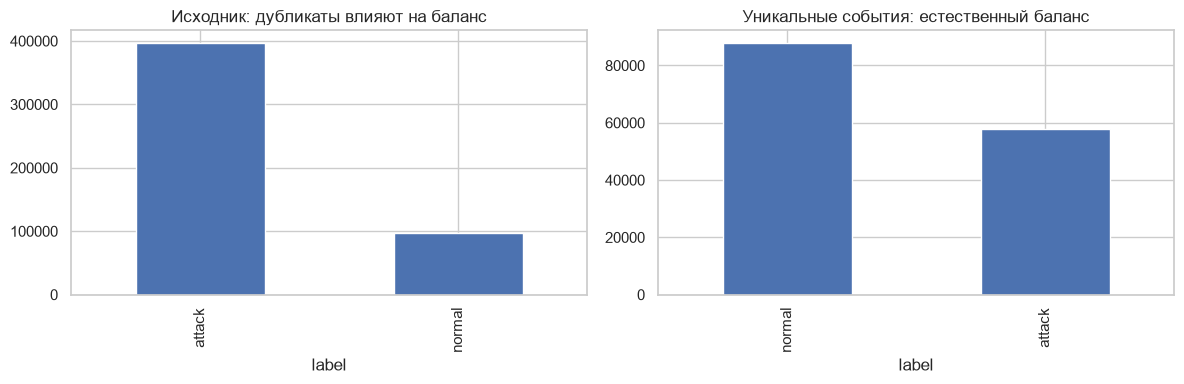

In [3]:
descriptions = {
    "duration": "Длительность соединения, секунды",
    "protocol_type": "Транспортный протокол",
    "service": "Сетевой сервис назначения",
    "flag": "Статус соединения",
    "src_bytes": "Байты от источника к получателю",
    "dst_bytes": "Байты в обратном направлении",
    "land": "Совпадают адреса/порты источника и назначения",
    "wrong_fragment": "Ошибочные фрагменты",
    "urgent": "Срочные пакеты",
    "hot": "Hot indicators",
    "num_failed_logins": "Неуспешные входы",
    "logged_in": "Успешный вход",
    "num_compromised": "Compromised conditions",
    "root_shell": "Root shell",
    "su_attempted": "Попытка su",
    "num_root": "Root accesses",
    "num_file_creations": "Создания файлов",
    "num_shells": "Shell prompts",
    "num_access_files": "Доступы к управляющим файлам",
    "num_outbound_cmds": "Исходящие FTP-команды",
    "is_host_login": "Host login",
    "is_guest_login": "Guest login",
    "count": "Соединения к тому же хосту за 2 секунды",
    "srv_count": "Соединения к тому же сервису за 2 секунды",
    "serror_rate": "Доля SYN errors",
    "srv_serror_rate": "Доля SYN errors для сервиса",
    "rerror_rate": "Доля REJ errors",
    "srv_rerror_rate": "Доля REJ errors для сервиса",
    "same_srv_rate": "Доля соединений к тому же сервису",
    "diff_srv_rate": "Доля других сервисов",
    "srv_diff_host_rate": "Доля других хостов для сервиса",
    "dst_host_count": "Счётчик соединений к dst host",
    "dst_host_srv_count": "Счётчик того же сервиса к dst host",
    "dst_host_same_srv_rate": "Доля того же сервиса к dst host",
    "dst_host_diff_srv_rate": "Доля других сервисов к dst host",
    "dst_host_same_src_port_rate": "Доля того же source port к dst host",
    "dst_host_srv_diff_host_rate": "Доля других хостов для dst service",
    "dst_host_serror_rate": "SYN errors для dst host",
    "dst_host_srv_serror_rate": "SYN errors для dst service",
    "dst_host_rerror_rate": "REJ errors для dst host",
    "dst_host_srv_rerror_rate": "REJ errors для dst service",
}
dictionary = pd.DataFrame(
    [
        {
            "feature": c,
            "description": descriptions[c],
            "dtype": str(raw[c].dtype),
            "missing": int(raw[c].isna().sum()),
            "unique": raw[c].nunique(),
        }
        for c in RAW_FEATURES
    ]
)
display(dictionary)
display(raw[RAW_FEATURES].describe(include="all").T)
display(raw.attack_type.value_counts().rename("rows").to_frame())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw.label.map({0: "normal", 1: "attack"}).value_counts().plot.bar(
    ax=axes[0], title="Исходник: дубликаты влияют на баланс"
)
pd.concat(splits.values()).label.map({0: "normal", 1: "attack"}).value_counts().plot.bar(
    ax=axes[1], title="Уникальные события: естественный баланс"
)
plt.tight_layout()
plt.show()

## 3. Train / validation / test: 60 / 20 / 20
    Split уже выполнен в загрузчике после очистки: два `train_test_split` с `stratify=label`, seed 42.
    Проверены непересечение векторов признаков и использование всех очищенных строк.
    Train — обучение преобразований, feature selection и моделей; validation — только порог;
    test — итоговые метрики после фиксации всех решений. Дальнейший EDA признаков использует train.

In [4]:
train_df, validation_df, test_df = (splits[k] for k in ["train", "validation", "test"])
split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(f),
            "normal": int((f.label == 0).sum()),
            "attack": int(f.label.sum()),
            "attack_rate": f.label.mean(),
        }
        for name, f in splits.items()
    ]
)
display(split_summary)
assert sum(split_summary.rows) == audit["unique_feature_rows"]
assert all(f.label.nunique() == 2 for f in splits.values())
X_train, y_train = train_df[RAW_FEATURES], train_df.label
display(
    train_df.groupby("protocol_type").agg(rows=("label", "size"), attack_rate=("label", "mean"))
)
display(
    train_df.groupby("service")
    .agg(rows=("label", "size"), attack_rate=("label", "mean"))
    .sort_values("rows", ascending=False)
    .head(15)
)

,split,rows,normal,attack,attack_rate
0,train,87349,52698,34651,0.396696
1,validation,29117,17566,11551,0.396710
2,test,29117,17567,11550,0.396675


,rows,attack_rate
protocol_type,,
icmp,1451,0.630600
tcp,78466,0.421036
udp,7432,0.094053


,rows,attack_rate
service,,
http,37309,0.019325
private,29434,0.970510
smtp,5743,0.011318
domain_u,3322,0.000301
other,2868,0.156904
ftp_data,2723,0.165626
ecr_i,597,0.827471
eco_i,578,0.726644
ftp,456,0.524123


## 4. Feature engineering
    Производные признаки строятся без label и без статистик holdout. Сглаживание `+1`
    исключает деление на ноль; `bytes_per_second` — демонстрационное приближение, не точная скорость.
    `log1p` показывает работу с тяжёлыми хвостами. На следующем шаге корреляционный отбор может
    удалить часть этих признаков: факт создания не гарантирует их полезность.
    Классы преобразований находятся в `src/ids_ml_lab/demo.py`, поэтому joblib загрузится и из CLI.

,formula
total_bytes,src_bytes + dst_bytes
src_byte_share,src_bytes / (total_bytes + 1)
bytes_per_second,total_bytes / (duration + 1); сглаженная интен...
zero_bytes,total_bytes == 0
srv_count_share,srv_count / (count + 1)
host_srv_share,dst_host_srv_count / (dst_host_count + 1)
log_duration,log1p(duration)
log_src_bytes,log1p(src_bytes)
log_dst_bytes,log1p(dst_bytes)
log_total_bytes,log1p(total_bytes)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,src_byte_share,bytes_per_second,zero_bytes,srv_count_share,host_srv_share,log_duration,log_src_bytes,log_dst_bytes,log_total_bytes,log_bytes_per_second
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.000000,0.0,1,0.078947,0.035156,0.0,0.000000,0.000000,0.000000,0.000000
1,0,tcp,http,SF,340,2366,0,0,0,0,...,0.125600,2706.0,0,1.125000,31.875000,0.0,5.831882,7.769379,7.903596,7.903596
2,0,icmp,eco_i,SF,30,0,0,0,0,0,...,0.967742,30.0,0,0.500000,0.980769,0.0,3.433987,0.000000,3.433987,3.433987
3,0,tcp,private,S0,0,0,0,0,0,0,...,0.000000,0.0,1,0.008130,0.003906,0.0,0.000000,0.000000,0.000000,0.000000
4,0,tcp,private,S0,0,0,0,0,0,0,...,0.000000,0.0,1,0.070922,0.027344,0.0,0.000000,0.000000,0.000000,0.000000


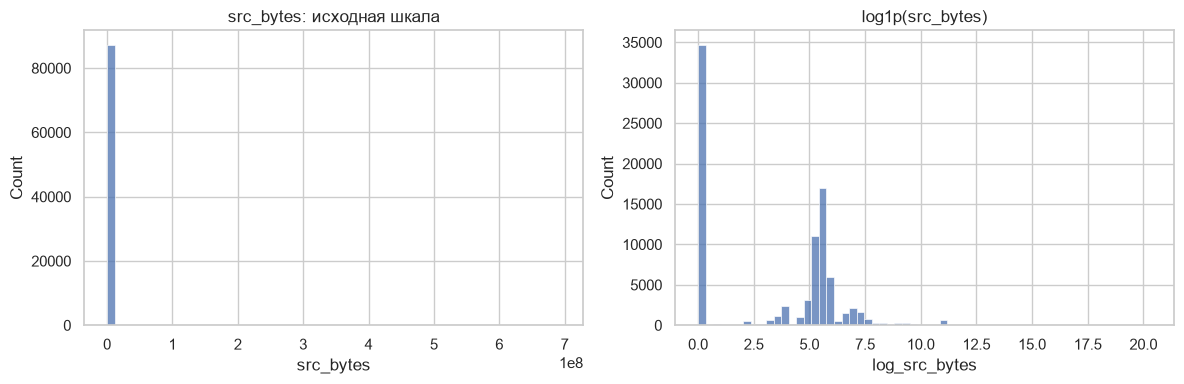

In [5]:
engineering = NetworkFeatures()
engineered_train = engineering.fit_transform(X_train)
display(pd.Series(DERIVED, name="formula").to_frame())
display(pd.concat([X_train.head(5), engineered_train[list(DERIVED)].head(5)], axis=1))
assert not np.isinf(engineered_train.select_dtypes("number").to_numpy()).any()
assert not {"label", "attack_type", "row_id"}.intersection(engineered_train.columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(engineered_train.src_bytes, bins=60, ax=axes[0])
axes[0].set_title("src_bytes: исходная шкала")
sns.histplot(engineered_train.log_src_bytes, bins=60, ax=axes[1])
axes[1].set_title("log1p(src_bytes)")
plt.tight_layout()
plt.show()

## 5. Отбор по корреляции
    Числовые признаки: Spearman, удаление при `|ρ| ≥ 0.90`. Сначала удаляются константы и
    полные дубликаты. Затем сохраняется первый признак в фиксированном порядке; label при этом
    не используется. Категории не превращаем в произвольные числа для Pearson/Spearman.
    Cramér’s V показывает их ассоциацию отдельно, без автоматического удаления.
    Отбор — демонстрация контроля избыточности, а не гарантия роста качества.

,removed,retained,correlation,reason
0,num_outbound_cmds,None,NaN,constant
1,is_host_login,None,NaN,constant
2,srv_serror_rate,serror_rate,0.988826,Spearman
3,srv_rerror_rate,rerror_rate,0.970886,Spearman
4,diff_srv_rate,same_srv_rate,-0.931290,Spearman
5,dst_host_same_srv_rate,dst_host_srv_count,0.951094,Spearman
6,dst_host_serror_rate,serror_rate,0.958178,Spearman
7,dst_host_srv_serror_rate,serror_rate,0.948872,Spearman
8,dst_host_srv_rerror_rate,dst_host_rerror_rate,0.921149,Spearman
9,total_bytes,dst_bytes,0.920209,Spearman


,selected_features
0,duration
1,protocol_type
2,service
3,flag
4,src_bytes
5,dst_bytes
6,land
7,wrong_fragment
8,urgent
9,hot


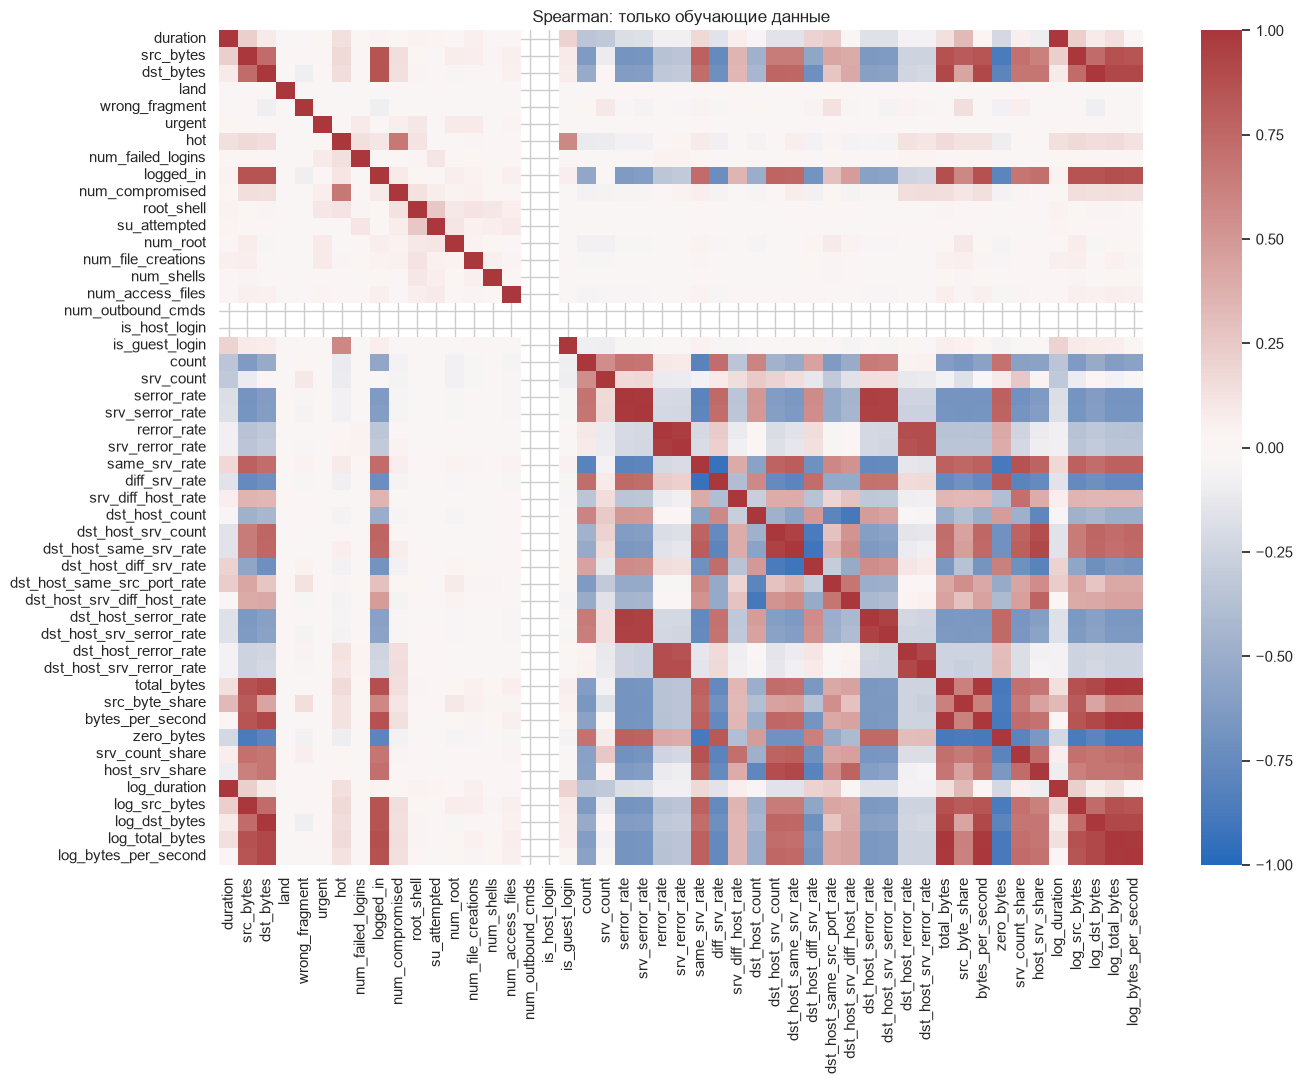

,left,right,cramers_v
0,protocol_type,service,0.929402
1,protocol_type,flag,0.194047
2,service,flag,0.308740


In [6]:
selection_fit = engineered_train.loc[y_train == 0] if ISOLATION else engineered_train
selector = CorrelationSelector(CORRELATION_THRESHOLD).fit(selection_fit)
display(selector.report_)
display(pd.Series(selector.selected_features_, name="selected_features").to_frame())
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(selector.correlation_, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman: только обучающие данные")
plt.tight_layout()
plt.show()
association_rows = []
for i, left in enumerate(CATEGORICAL_FEATURES):
    for right in CATEGORICAL_FEATURES[i + 1 :]:
        table = pd.crosstab(selection_fit[left], selection_fit[right])
        value = (
            np.sqrt(
                chi2_contingency(table, correction=False)[0]
                / (table.to_numpy().sum() * (min(table.shape) - 1))
            )
            if min(table.shape) > 1
            else np.nan
        )
        association_rows.append({"left": left, "right": right, "cramers_v": value})
display(pd.DataFrame(association_rows))

## 6. Обучение моделей
    Logistic Regression и CatBoost обучаются на **всём train с labels**. LR использует StandardScaler и OneHotEncoder; CatBoost — исходные категории и числовые признаки после общего feature engineering/selection. Параметры фиксированы заранее; early stopping на test отсутствует. Вероятности не считаем автоматически откалиброванными.
    Сохранённый pipeline содержит все преобразования от 41 исходного признака до модели.

In [7]:
pipelines, training_times, scores = {}, {}, {}
for kind in KINDS:
    pipeline = make_demo_pipeline(kind, seed=SEED, correlation_threshold=CORRELATION_THRESHOLD)
    started = time.perf_counter()
    if kind == "iforest":
        pipeline.fit(X_train.loc[y_train == 0])
    else:
        pipeline.fit(X_train, y_train)
    training_times[kind] = time.perf_counter() - started
    pipelines[kind] = pipeline
    scores[kind] = {
        name: model_scores(pipeline, f[RAW_FEATURES], kind)
        for name, f in splits.items()
        if name != "test"
    }
    display(
        pd.Series(
            {
                "model": kind,
                "fit_rows": int((y_train == 0).sum()) if kind == "iforest" else len(y_train),
                "selected_features": len(pipeline.named_steps["selection"].selected_features_),
                "fit_seconds": training_times[kind],
            }
        ).to_frame()
    )
    display(pd.Series(pipeline.named_steps["model"].get_params()).to_frame("parameters"))

,0
model,logreg
fit_rows,87349
selected_features,36
fit_seconds,1.880138


,parameters
C,1
class_weight,None
dual,False
fit_intercept,True
intercept_scaling,1
l1_ratio,0.0
max_iter,3000
n_jobs,None
penalty,deprecated
random_state,42


,0
model,catboost
fit_rows,87349
selected_features,36
fit_seconds,7.692545


,parameters
iterations,250
learning_rate,0.08
depth,6
loss_function,Logloss
thread_count,4
random_seed,42
verbose,False
allow_writing_files,False
cat_features,"[protocol_type, service, flag]"


## 7. 5-fold cross-validation на train
    Каждый fold заново обучает **весь pipeline**, включая корреляционный отбор и scaling.
    Для Isolation Forest fit использует только normal-часть fold; heldout содержит оба класса.
    Таблица mean/std описывает устойчивость обучения, не заменяет доверительные интервалы test.

logreg: fold 1/5 completed
logreg: fold 2/5 completed
logreg: fold 3/5 completed
logreg: fold 4/5 completed
logreg: fold 5/5 completed
catboost: fold 1/5 completed
catboost: fold 2/5 completed
catboost: fold 3/5 completed
catboost: fold 4/5 completed
catboost: fold 5/5 completed
logreg


,fold,roc_auc,average_precision,n_features
0,1,0.998973,0.998393,36
1,2,0.998879,0.998881,36
2,3,0.998766,0.998683,36
3,4,0.999336,0.998376,36
4,5,0.999105,0.997264,36


,roc_auc,average_precision
mean,0.999012,0.998320
std,0.000220,0.000626
min,0.998766,0.997264
max,0.999336,0.998881


catboost


,fold,roc_auc,average_precision,n_features
0,1,0.999981,0.999973,36
1,2,0.999995,0.999992,36
2,3,0.999991,0.999986,36
3,4,0.999996,0.999994,36
4,5,0.999997,0.999996,36


,roc_auc,average_precision
mean,0.999992,0.999988
std,0.000007,0.000009
min,0.999981,0.999973
max,0.999997,0.999996


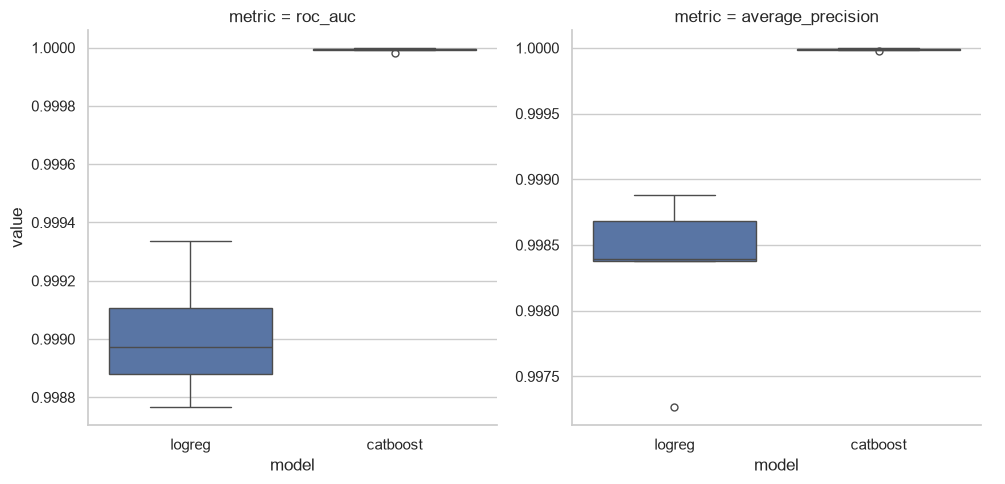

In [8]:
cv_results = {
    kind: demo_cv(pipelines[kind], X_train, y_train, kind, folds=5, seed=SEED) for kind in KINDS
}
for kind, frame in cv_results.items():
    print(kind)
    display(frame)
    display(frame[["roc_auc", "average_precision"]].agg(["mean", "std", "min", "max"]))
cv_long = pd.concat([f.assign(model=k) for k, f in cv_results.items()]).melt(
    id_vars=["model", "fold"],
    value_vars=["roc_auc", "average_precision"],
    var_name="metric",
    value_name="value",
)
sns.catplot(data=cv_long, x="model", y="value", col="metric", kind="box", sharey=False)
plt.show()

## 8. Выбор порога на validation
    Для каждой модели выбираем максимум F1 при **FPR ≤ 5%** на validation.
    Проверяем все уникальные score, включая порог «нет тревог», учитываем равенство `score ≥ threshold`.
    При одинаковом F1 предпочитаем меньший FPR. Ни порог, ни параметры не выбираются по test.
    После этой ячейки решения заморожены. FPR на test может отличаться от validation.

,logreg
roc_auc,0.999251
average_precision,0.998706
gini,0.998503
accuracy,0.995638
balanced_accuracy,0.995525
precision,0.994032
recall,0.994979
f1,0.994505
specificity,0.996072
fpr,0.003928


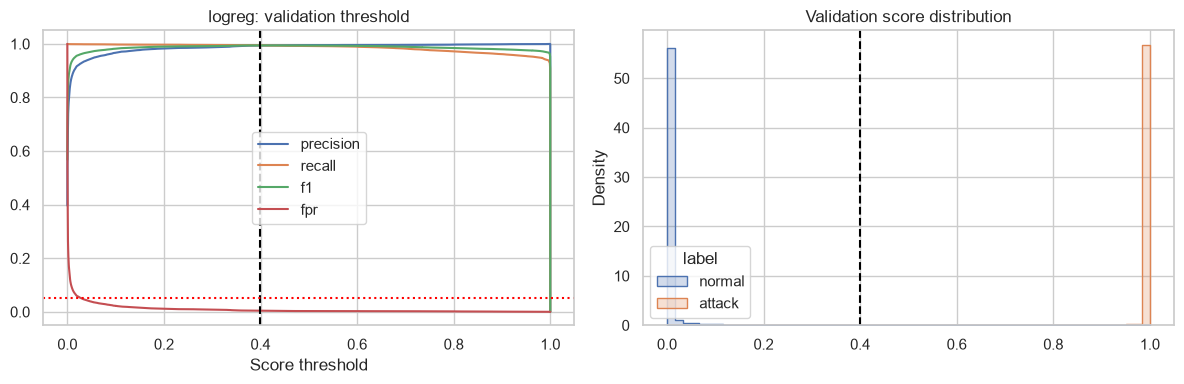

,catboost
roc_auc,0.999995
average_precision,0.999993
gini,0.999991
accuracy,0.999519
balanced_accuracy,0.999513
precision,0.999308
recall,0.999481
f1,0.999394
specificity,0.999545
fpr,0.000455


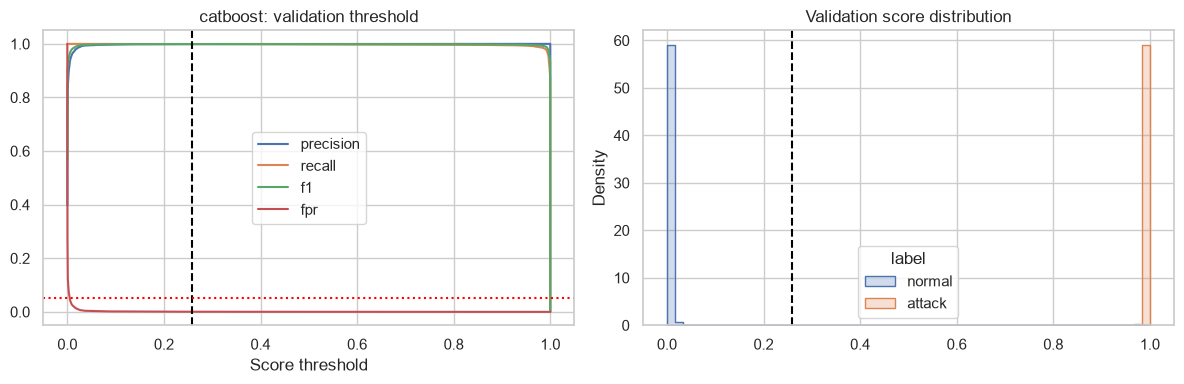

In [9]:
thresholds, threshold_candidates = {}, {}
for kind in KINDS:
    table = threshold_table(validation_df.label.to_numpy(), scores[kind]["validation"])
    threshold = choose_threshold(table, MAX_FPR)
    thresholds[kind], threshold_candidates[kind] = threshold, table
    metrics = evaluate(
        validation_df.label.to_numpy(), scores[kind]["validation"], threshold, kind != "iforest"
    )
    assert metrics["fpr"] <= MAX_FPR
    display(pd.Series(metrics, name=kind).to_frame())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for col in ["precision", "recall", "f1", "fpr"]:
        axes[0].plot(table.threshold, table[col], label=col)
    axes[0].axvline(threshold, color="black", linestyle="--")
    axes[0].axhline(MAX_FPR, color="red", linestyle=":")
    axes[0].set(title=f"{kind}: validation threshold", xlabel="Score threshold")
    axes[0].legend()
    sns.histplot(
        x=scores[kind]["validation"],
        hue=validation_df.label.map({0: "normal", 1: "attack"}),
        bins=60,
        stat="density",
        common_norm=False,
        element="step",
        ax=axes[1],
    )
    axes[1].axvline(threshold, color="black", linestyle="--")
    axes[1].set_title("Validation score distribution")
    plt.tight_layout()
    plt.show()

## 9. Финальные метрики на test
    Положительный класс — атака. AP (`average_precision`) — ступенчатая площадь PR, не
    трапецеидальная PR AUC. ROC AUC/KS измеряют разделение; precision/recall/F1 зависят от порога.
    FPR — доля ложных тревог среди normal, FNR — доля пропущенных атак; MCC учитывает все ячейки матрицы.
    Для supervised моделей дополнительно считаем log loss и Brier; для anomaly score они неприменимы.
    Train — in-sample диагностика, validation участвовала в выборе порога, test — итоговая оценка.

model                    logreg                                  catboost  \
split                     train    validation          test         train   
roc_auc                0.999142      0.999251      0.998883      0.999999   
average_precision      0.999200      0.998706      0.998640      0.999999   
gini                   0.998284      0.998503      0.997766      0.999998   
accuracy               0.995547      0.995638      0.995638      0.999588   
balanced_accuracy      0.995410      0.995525      0.995362      0.999609   
precision              0.994030      0.994032      0.994974      0.999250   
recall                 0.994748      0.994979      0.994026      0.999711   
f1                     0.994389      0.994505      0.994500      0.999481   
specificity            0.996072      0.996072      0.996698      0.999507   
fpr                    0.003928      0.003928      0.003302      0.000493   
fnr                    0.005252      0.005021      0.005974      0.000289   
mcc                    0.990697      0.990889      0.990886      0.999139   
ks                     0.990895      0.991051      0.990809      0.999248   
ks_pvalue              0.000000      0.000000      0.000000      0.000000   
threshold              0.399215      0.399215      0.399215      0.258827   
tn                 52491.000000  17497.000000  17509.000000  52672.000000   
fp                   207.000000     69.000000     58.000000     26.000000   
fn                   182.000000     58.000000     69.000000     10.000000   
tp                 34469.000000  11493.000000  11481.000000  34641.000000   
log_loss               0.021230      0.021832      0.023166      0.002087   
brier                  0.004510      0.004747      0.004442      0.000372   

model                                          
split                validation          test  
roc_auc                0.999995      0.999962  
average_precision      0.999993      0.999954  
gini                   0.999991      0.999925  
accuracy               0.999519      0.999485  
balanced_accuracy      0.999513      0.999425  
precision              0.999308      0.999567  
recall                 0.999481      0.999134  
f1                     0.999394      0.999351  
specificity            0.999545      0.999715  
fpr                    0.000455      0.000285  
fnr                    0.000519      0.000866  
mcc                    0.998996      0.998924  
ks                     0.999025      0.999023  
ks_pvalue              0.000000      0.000000  
threshold              0.258827      0.258827  
tn                 17558.000000  17562.000000  
fp                     8.000000      5.000000  
fn                     6.000000     10.000000  
tp                 11545.000000  11540.000000  
log_loss               0.002891      0.003070  
brier                  0.000618      0.000579

logreg test classification report


,precision,recall,f1-score,support
normal,0.996075,0.996698,0.996386,17567.000000
attack,0.994974,0.994026,0.994500,11550.000000
accuracy,0.995638,0.995638,0.995638,0.995638
macro avg,0.995524,0.995362,0.995443,29117.000000
weighted avg,0.995638,0.995638,0.995638,29117.000000


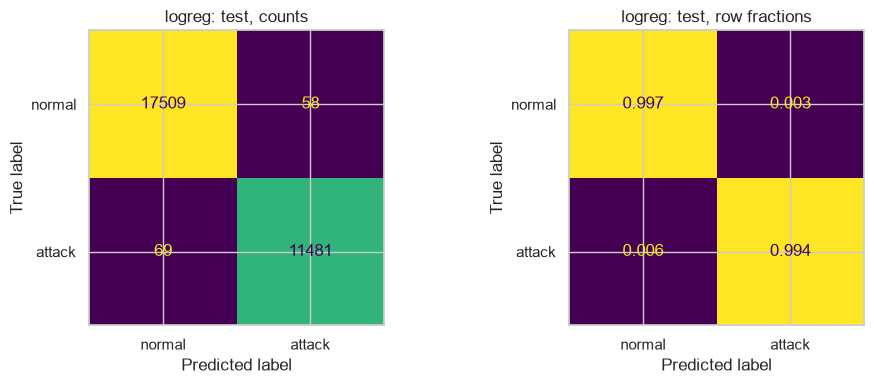

catboost test classification report


,precision,recall,f1-score,support
normal,0.999431,0.999715,0.999573,17567.000000
attack,0.999567,0.999134,0.999351,11550.000000
accuracy,0.999485,0.999485,0.999485,0.999485
macro avg,0.999499,0.999425,0.999462,29117.000000
weighted avg,0.999485,0.999485,0.999485,29117.000000


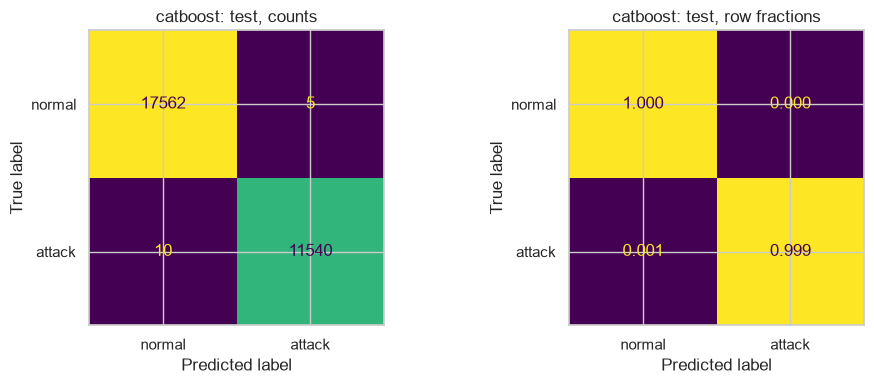

In [10]:
metrics_rows, reports = [], {}
for kind in KINDS:
    scores[kind]["test"] = model_scores(pipelines[kind], test_df[RAW_FEATURES], kind)
    reports[kind] = {}
    for name, f in splits.items():
        result = evaluate(
            f.label.to_numpy(), scores[kind][name], thresholds[kind], kind != "iforest"
        )
        reports[kind][name] = result
        metrics_rows.append({"model": kind, "split": name, **result})
metrics_table = pd.DataFrame(metrics_rows).set_index(["model", "split"])
display(metrics_table.T)
for kind in KINDS:
    pred = (scores[kind]["test"] >= thresholds[kind]).astype(int)
    print(kind, "test classification report")
    display(
        pd.DataFrame(
            classification_report(
                test_df.label,
                pred,
                target_names=["normal", "attack"],
                output_dict=True,
                zero_division=0,
            )
        ).T
    )
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, norm in zip(axes, [None, "true"], strict=True):
        ConfusionMatrixDisplay.from_predictions(
            test_df.label,
            pred,
            labels=[0, 1],
            display_labels=["normal", "attack"],
            normalize=norm,
            ax=ax,
            colorbar=False,
            values_format="d" if norm is None else ".3f",
        )
        ax.set_title(f"{kind}: test, " + ("counts" if norm is None else "row fractions"))
    plt.tight_layout()
    plt.show()

## 10. ROC, Precision–Recall, KS и распределения score

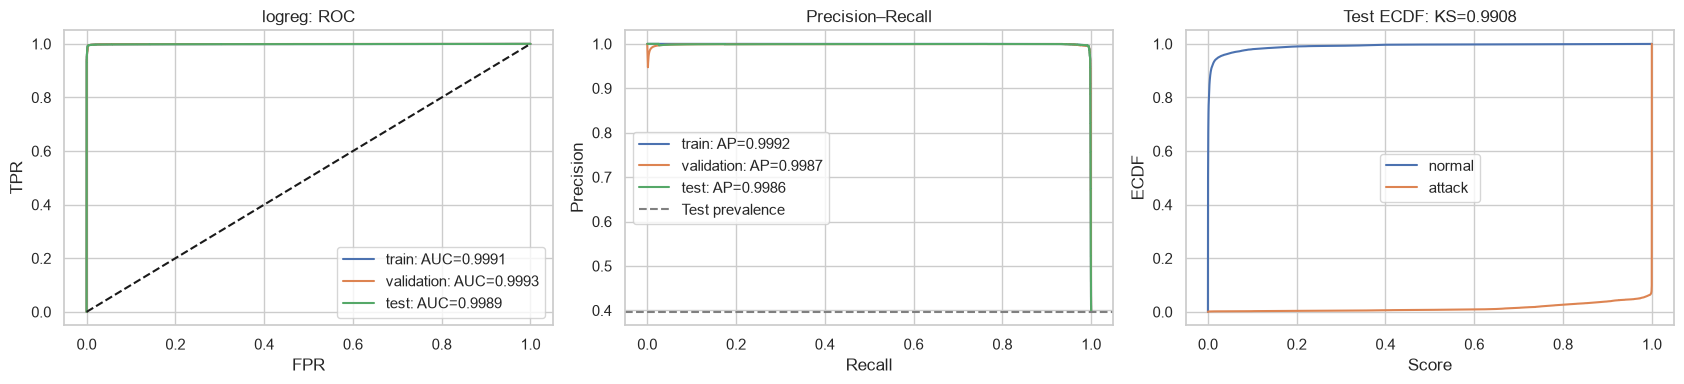

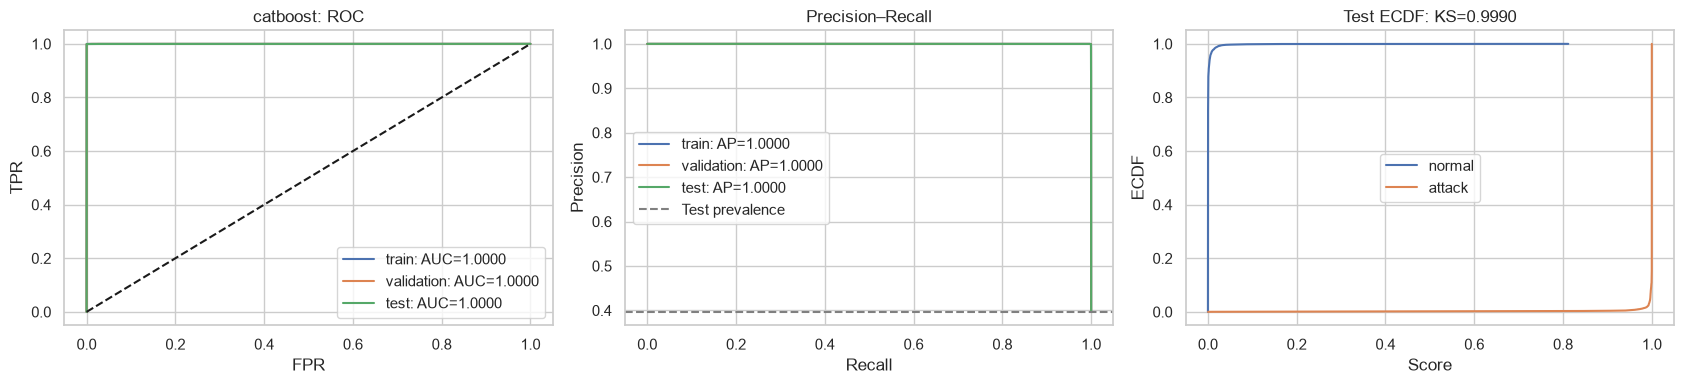

In [11]:
for kind in KINDS:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    for name, f in splits.items():
        yy, ss = f.label.to_numpy(), scores[kind][name]
        fpr, tpr, _ = roc_curve(yy, ss)
        precision, recall, _ = precision_recall_curve(yy, ss)
        axes[0].plot(fpr, tpr, label=f"{name}: AUC={reports[kind][name]['roc_auc']:.4f}")
        axes[1].plot(
            recall, precision, label=f"{name}: AP={reports[kind][name]['average_precision']:.4f}"
        )
    axes[0].plot([0, 1], [0, 1], "k--")
    axes[0].set(title=f"{kind}: ROC", xlabel="FPR", ylabel="TPR")
    axes[1].axhline(test_df.label.mean(), linestyle="--", color="gray", label="Test prevalence")
    axes[1].set(title="Precision–Recall", xlabel="Recall", ylabel="Precision")
    for label, title in [(0, "normal"), (1, "attack")]:
        values = np.sort(scores[kind]["test"][test_df.label.to_numpy() == label])
        axes[2].plot(values, np.arange(1, len(values) + 1) / len(values), label=title)
    axes[2].set(
        title=f"Test ECDF: KS={reports[kind]['test']['ks']:.4f}", xlabel="Score", ylabel="ECDF"
    )
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()

## 11. 95% интервальные оценки
    300 обычных paired bootstrap повторов test с seed 42: пересэмплируем пары label/score.
    Модель и validation threshold фиксированы; интервалы условны на обученную модель и не
    учитывают повторное обучение, выбор порога или сетевую зависимость событий.
    Повторы с одним классом пропускаются. Малые сегменты не получают обещаний точности.

,metric,estimate,low_95,high_95,replicates,model
0,roc_auc,0.998883,0.998398,0.999354,300,logreg
1,average_precision,0.998640,0.997847,0.999293,300,logreg
2,gini,0.997766,0.996797,0.998707,300,logreg
3,accuracy,0.995638,0.994883,0.996309,300,logreg
4,balanced_accuracy,0.995362,0.994506,0.996116,300,logreg
5,precision,0.994974,0.994003,0.996227,300,logreg
6,recall,0.994026,0.992371,0.995392,300,logreg
7,f1,0.994500,0.993544,0.995359,300,logreg
8,specificity,0.996698,0.996046,0.997520,300,logreg
9,fpr,0.003302,0.002480,0.003954,300,logreg


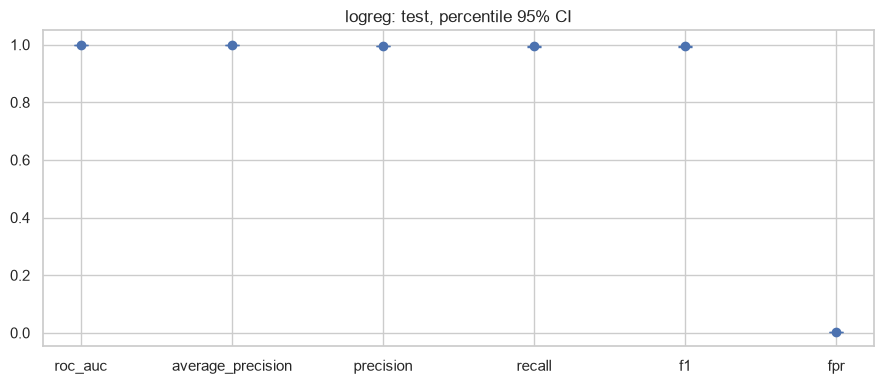

,metric,estimate,low_95,high_95,replicates,model
0,roc_auc,0.999962,0.999908,0.999997,300,catboost
1,average_precision,0.999954,0.999894,0.999995,300,catboost
2,gini,0.999925,0.999816,0.999994,300,catboost
3,accuracy,0.999485,0.999226,0.999691,300,catboost
4,balanced_accuracy,0.999425,0.999128,0.999669,300,catboost
5,precision,0.999567,0.999132,0.999913,300,catboost
6,recall,0.999134,0.998540,0.999652,300,catboost
7,f1,0.999351,0.999030,0.999611,300,catboost
8,specificity,0.999715,0.999429,0.999943,300,catboost
9,fpr,0.000285,0.000057,0.000571,300,catboost


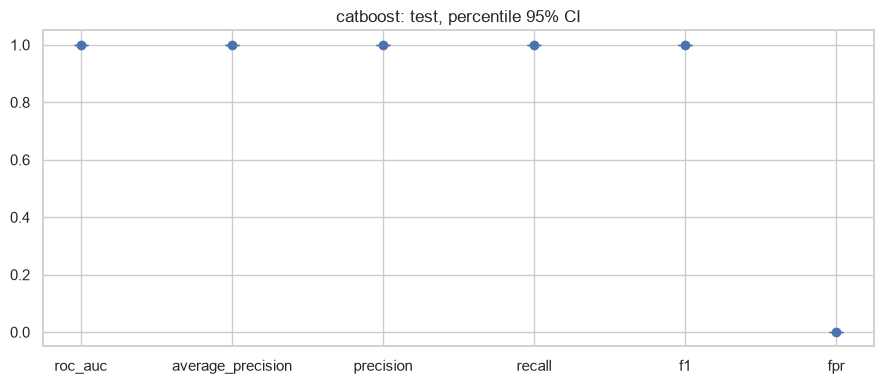

In [12]:
confidence_intervals = {}
for kind in KINDS:
    ci = bootstrap_metrics(
        test_df.label.to_numpy(),
        scores[kind]["test"],
        thresholds[kind],
        kind != "iforest",
        iterations=BOOTSTRAP_ITERATIONS,
        seed=SEED,
    )
    confidence_intervals[kind] = ci
    display(ci.assign(model=kind))
    subset = ci.set_index("metric").loc[
        ["roc_auc", "average_precision", "precision", "recall", "f1", "fpr"]
    ]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.errorbar(
        np.arange(len(subset)),
        subset.estimate,
        yerr=[
            np.maximum(0, subset.estimate - subset.low_95),
            np.maximum(0, subset.high_95 - subset.estimate),
        ],
        fmt="o",
        capsize=5,
    )
    ax.set_xticks(np.arange(len(subset)), subset.index)
    ax.set_title(f"{kind}: test, percentile 95% CI")
    plt.tight_layout()
    plt.show()

## 12. Срезы и ошибки
    По типам атак показываем число событий, обнаруженные/пропущенные атаки и recall.
    ROC AUC не вычисляется для групп с одним классом. Для протоколов/сервисов показываем
    размер группы и FPR/recall только если соответствующий класс присутствует.
    Здесь анализируем ошибки уже зафиксированных моделей, не подбираем новые параметры.

In [13]:
for kind in KINDS:
    diagnostic = test_df.copy()
    diagnostic["score"] = scores[kind]["test"]
    diagnostic["prediction"] = (diagnostic.score >= thresholds[kind]).astype(int)
    attacks = (
        diagnostic.loc[diagnostic.label == 1]
        .groupby("attack_type")
        .agg(n=("label", "size"), detected=("prediction", "sum"))
    )
    attacks["missed"] = attacks.n - attacks.detected
    attacks["recall"] = attacks.detected / attacks.n
    print(kind)
    display(attacks.sort_values("recall"))
    segment_rows = []
    for column in ["protocol_type", "service"]:
        for segment, f in diagnostic.groupby(column):
            normal, attack = f.loc[f.label == 0], f.loc[f.label == 1]
            segment_rows.append(
                {
                    "column": column,
                    "segment": segment,
                    "n": len(f),
                    "normal_n": len(normal),
                    "attack_n": len(attack),
                    "fpr": normal.prediction.mean() if len(normal) else np.nan,
                    "recall": attack.prediction.mean() if len(attack) else np.nan,
                }
            )
    display(pd.DataFrame(segment_rows).sort_values("n", ascending=False).head(25))
    display(
        diagnostic.loc[
            diagnostic.label != diagnostic.prediction,
            [
                "row_id",
                "protocol_type",
                "service",
                "attack_type",
                "label",
                "prediction",
                "score",
                "src_bytes",
                "dst_bytes",
            ],
        ].head(12)
    )

logreg


,n,detected,missed,recall
attack_type,,,,
rootkit,1,0,1,0.000000
multihop,1,0,1,0.000000
warezmaster,4,2,2,0.500000
imap,4,2,2,0.500000
buffer_overflow,7,4,3,0.571429
ipsweep,115,100,15,0.869565
warezclient,187,172,15,0.919786
smurf,126,116,10,0.920635
satan,185,173,12,0.935135


,column,segment,n,normal_n,attack_n,fpr,recall
1,protocol_type,tcp,26224,15164,11060,0.003297,0.996112
25,service,http,12363,12119,244,0.001403,0.991803
48,service,private,9768,311,9457,0.003215,0.999154
2,protocol_type,udp,2447,2241,206,0.001785,0.966019
52,service,smtp,2030,1992,38,0.001506,0.921053
14,service,domain_u,1070,1070,0,0.000000,NaN
43,service,other,940,799,141,0.011264,0.971631
22,service,ftp_data,894,733,161,0.006821,0.875776
0,protocol_type,icmp,446,162,284,0.024691,0.933099
17,service,ecr_i,201,29,172,0.034483,0.936047


,row_id,protocol_type,service,attack_type,label,prediction,score,src_bytes,dst_bytes
4,485161,icmp,eco_i,ipsweep,1,0,0.267031,18,0
318,76323,tcp,imap4,imap,1,0,0.000880,1492,649186
612,19439,tcp,http,normal,0,1,0.740954,228,177
713,450316,icmp,eco_i,normal,0,1,0.633356,30,0
921,142156,tcp,ftp_data,warezclient,1,0,0.095793,334,0
1129,141888,tcp,ftp_data,warezclient,1,0,0.008101,334,0
1313,149317,tcp,other,normal,0,1,0.687833,26408,0
1369,148773,icmp,ecr_i,ipsweep,1,0,0.221723,8,0
1459,485158,icmp,eco_i,ipsweep,1,0,0.391288,18,0
1630,149490,udp,other,satan,1,0,0.000963,1,0


catboost


,n,detected,missed,recall
attack_type,,,,
imap,4,2,2,0.500000
warezmaster,4,3,1,0.750000
ipsweep,115,112,3,0.973913
satan,185,182,3,0.983784
warezclient,187,186,1,0.994652
teardrop,167,167,0,1.000000
smurf,126,126,0,1.000000
rootkit,1,1,0,1.000000
portsweep,97,97,0,1.000000


,column,segment,n,normal_n,attack_n,fpr,recall
1,protocol_type,tcp,26224,15164,11060,0.000264,0.999186
25,service,http,12363,12119,244,0.000000,1.000000
48,service,private,9768,311,9457,0.000000,1.000000
2,protocol_type,udp,2447,2241,206,0.000000,1.000000
52,service,smtp,2030,1992,38,0.000000,0.947368
14,service,domain_u,1070,1070,0,0.000000,NaN
43,service,other,940,799,141,0.000000,1.000000
22,service,ftp_data,894,733,161,0.001364,0.981366
0,protocol_type,icmp,446,162,284,0.006173,0.996479
17,service,ecr_i,201,29,172,0.000000,1.000000


,row_id,protocol_type,service,attack_type,label,prediction,score,src_bytes,dst_bytes
318,76323,tcp,imap4,imap,1,0,0.009988,1492,649186
3710,484572,icmp,tim_i,normal,0,1,0.603530,564,0
4952,344013,icmp,urp_i,satan,1,0,0.005805,37,0
6758,91630,tcp,pm_dump,satan,1,0,0.103296,44,192
11417,148729,tcp,ftp_data,warezclient,1,0,0.240642,334,0
12065,76466,tcp,telnet,normal,0,1,0.811822,158,226
12373,26526,tcp,smtp,ipsweep,1,0,0.001500,0,91
16780,369933,tcp,ftp_data,normal,0,1,0.683606,12,0
17231,140596,tcp,smtp,satan,1,0,0.000328,1710,375
18070,32201,tcp,telnet,normal,0,1,0.336434,24,36


## 13. SHAP: глобальная важность и локальные случаи
    SHAP объясняет поведение модели, не причинность и не истинность security verdict.
    Фон LR берём только из train. Выборка test для объяснения фиксирована seed; добавляем
    представителей TP/TN/FP/FN, если такие случаи существуют. Глобальная важность считается
только на случайной выборке, локальные примеры ошибок её не смещают.
    LR объясняет **log odds**, CatBoost native SHAP — **raw margin/log odds**;
    Isolation Forest TreeExplainer — **среднюю длину пути**, а не anomaly score.
    Для леса более короткий путь означает более высокую аномальность. Проверяем восстановление
    score через `2**(-path_length/c(max_samples)) + offset`.
    Категории CatBoost на beeswarm показаны кодами только для цвета; модель обучена на строках.
    [CatBoost SHAP](https://catboost.ai/docs/en/concepts/shap-values),
    [SHAP TreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html).

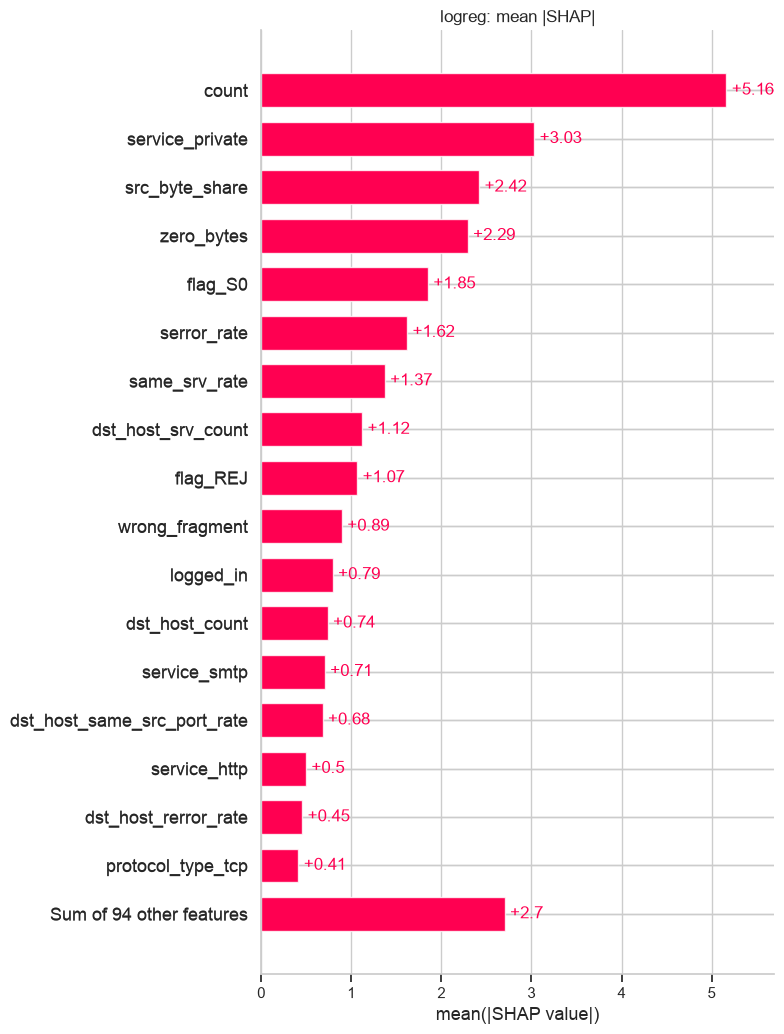

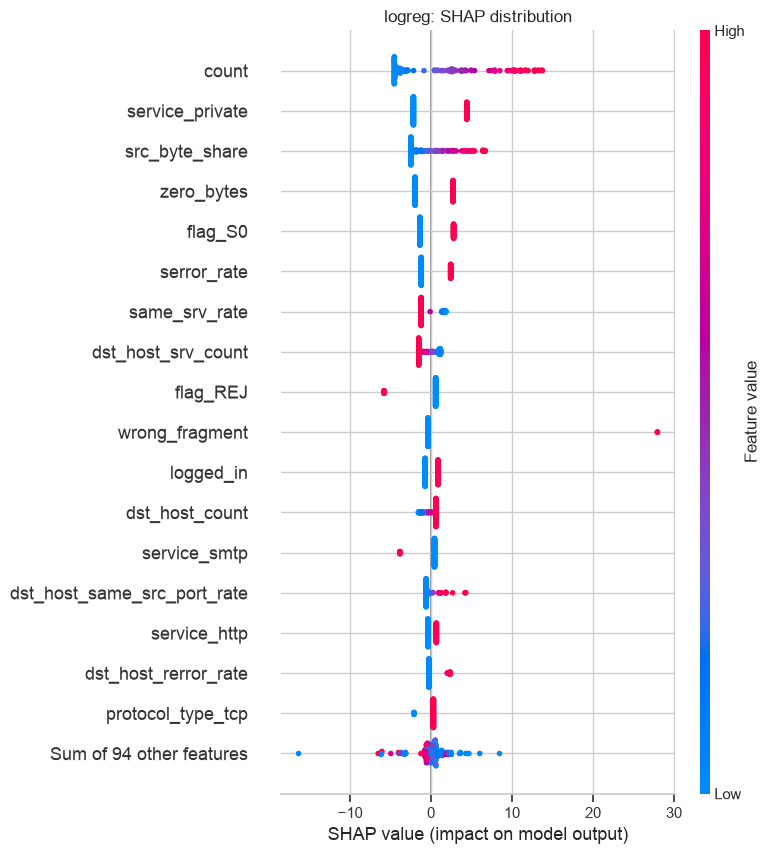

,feature,mean_abs_shap
17,count,5.163618
80,service_private,3.030509
29,src_byte_share,2.419110
30,zero_bytes,2.291790
105,flag_S0,1.850181
19,serror_rate,1.619407
21,same_srv_rate,1.370968
24,dst_host_srv_count,1.120030
101,flag_REJ,1.065209
4,wrong_fragment,0.894881


logreg TP true= 1 score= 0.9999999999965408 threshold= 0.3992147605399028


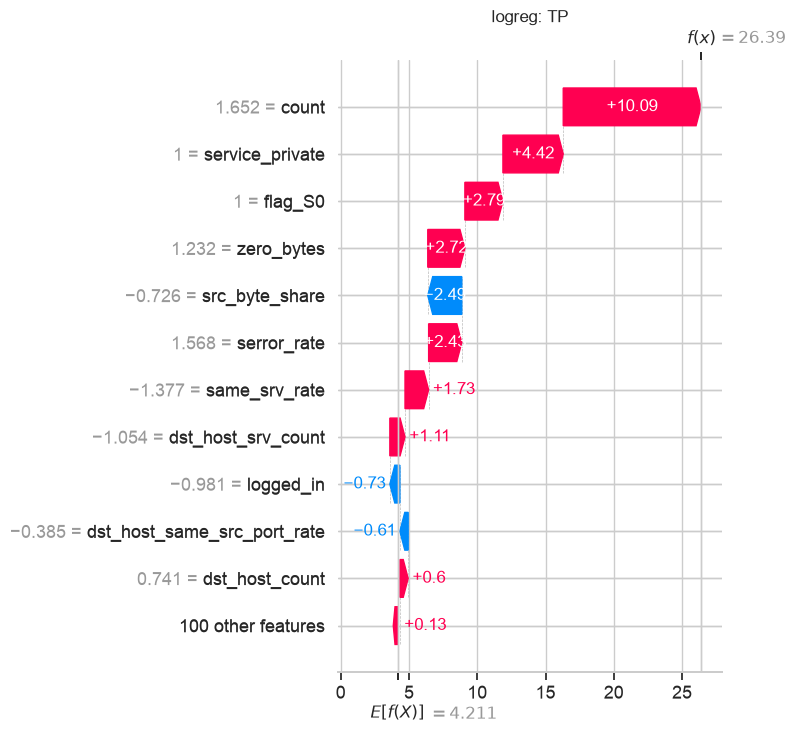

logreg TN true= 0 score= 0.0006115141171828988 threshold= 0.3992147605399028


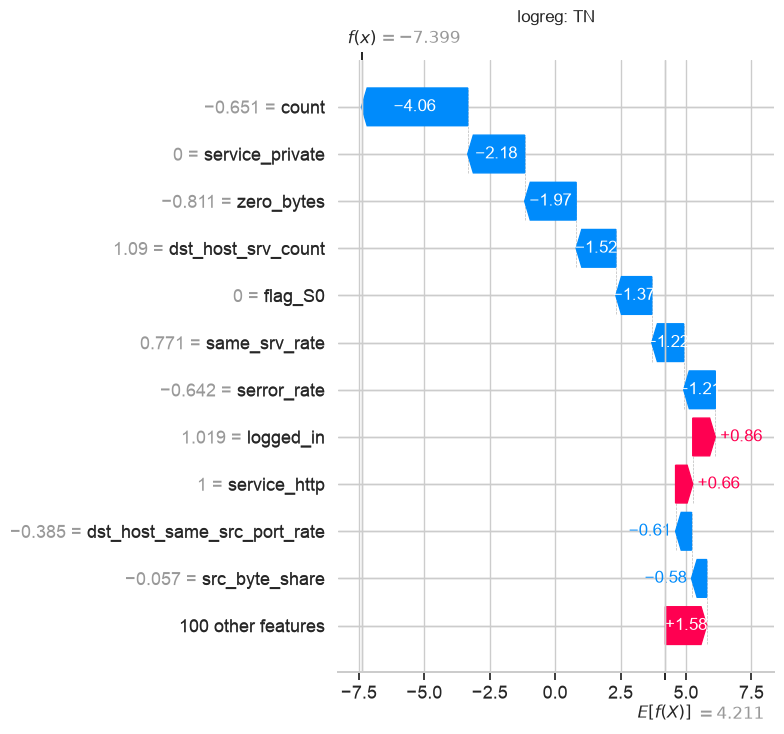

logreg FP true= 0 score= 0.7409543444991658 threshold= 0.3992147605399028


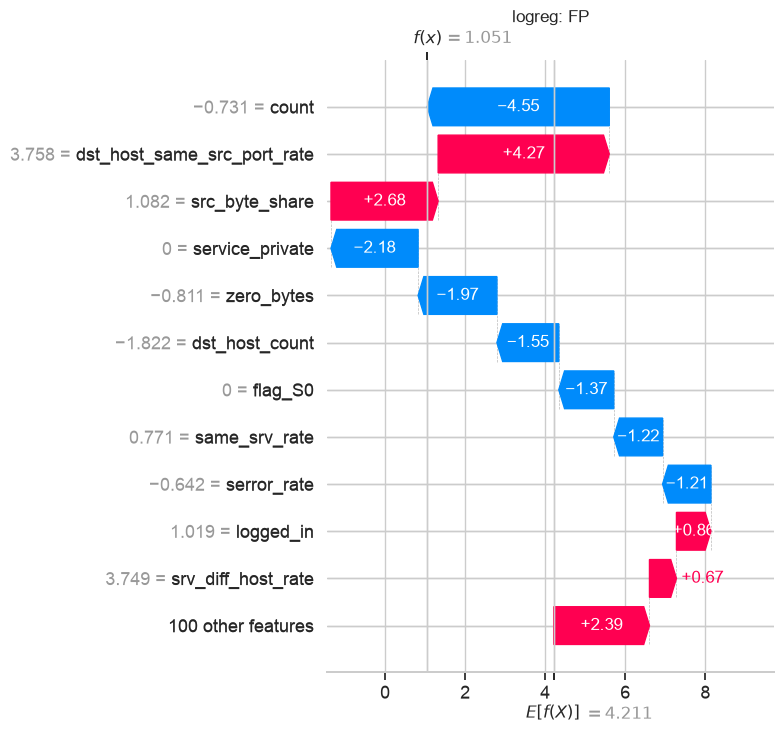

logreg FN true= 1 score= 0.26703100236959626 threshold= 0.3992147605399028


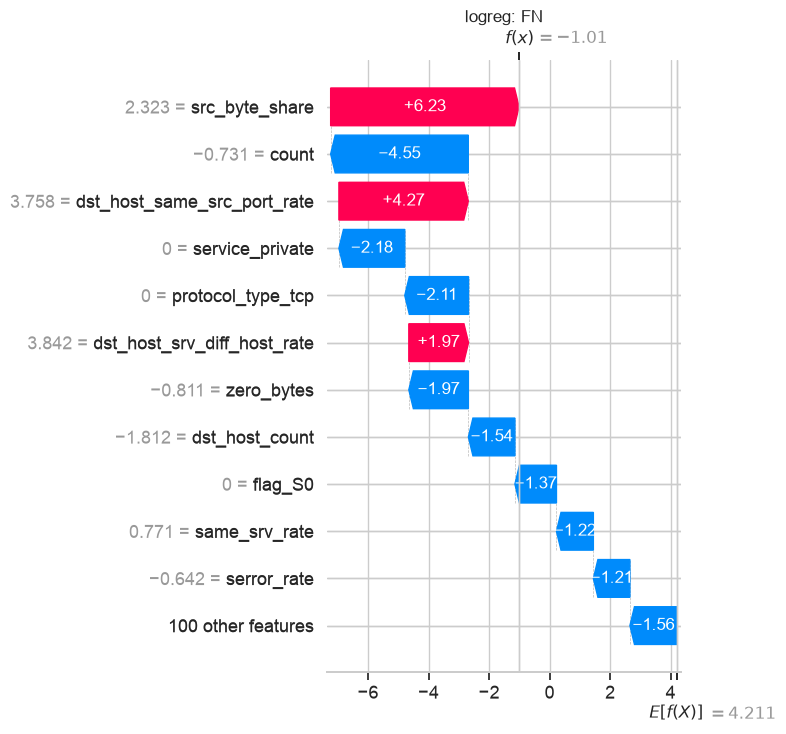

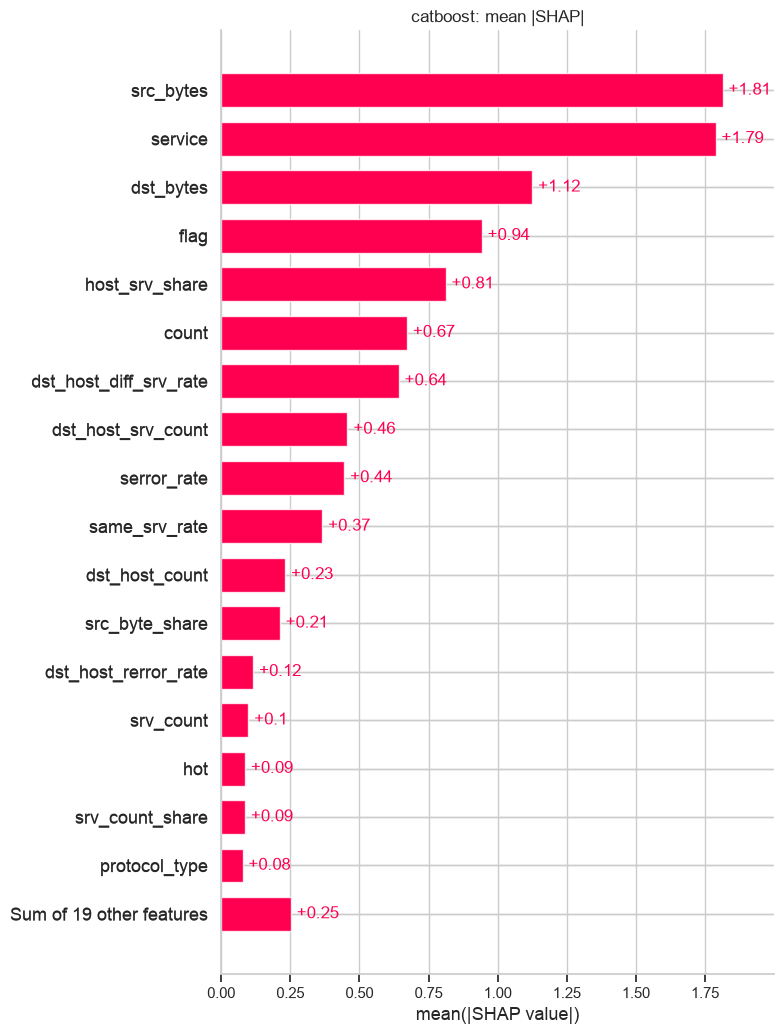

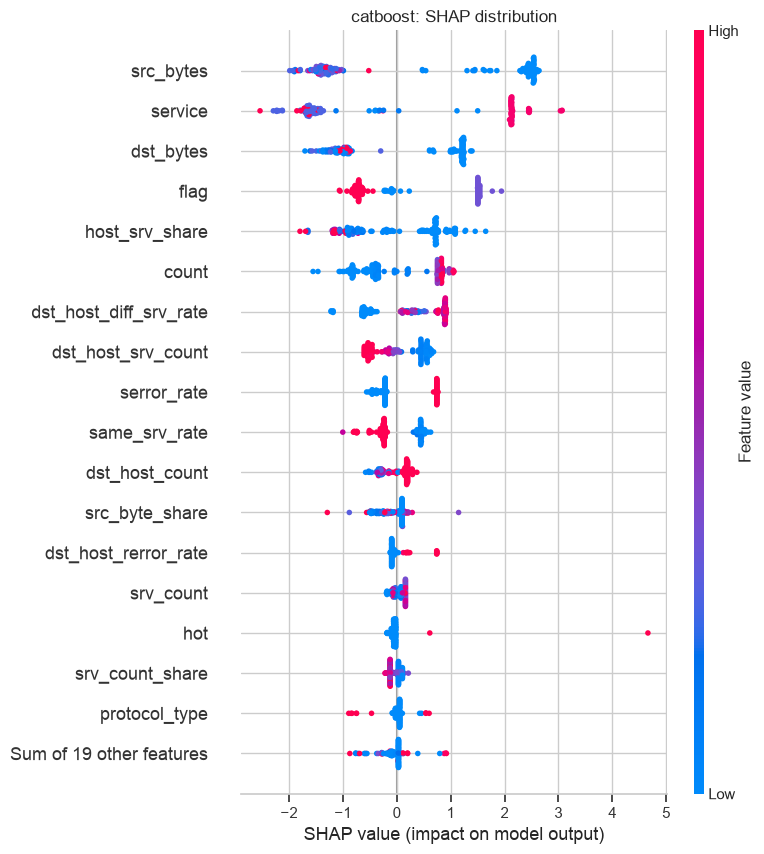

,feature,mean_abs_shap
4,src_bytes,1.813395
2,service,1.788006
5,dst_bytes,1.124938
3,flag,0.942150
35,host_srv_share,0.811520
20,count,0.671730
28,dst_host_diff_srv_rate,0.641865
27,dst_host_srv_count,0.456505
22,serror_rate,0.444878
24,same_srv_rate,0.365376


catboost TP true= 1 score= 0.9999755111321207 threshold= 0.25882705447098736


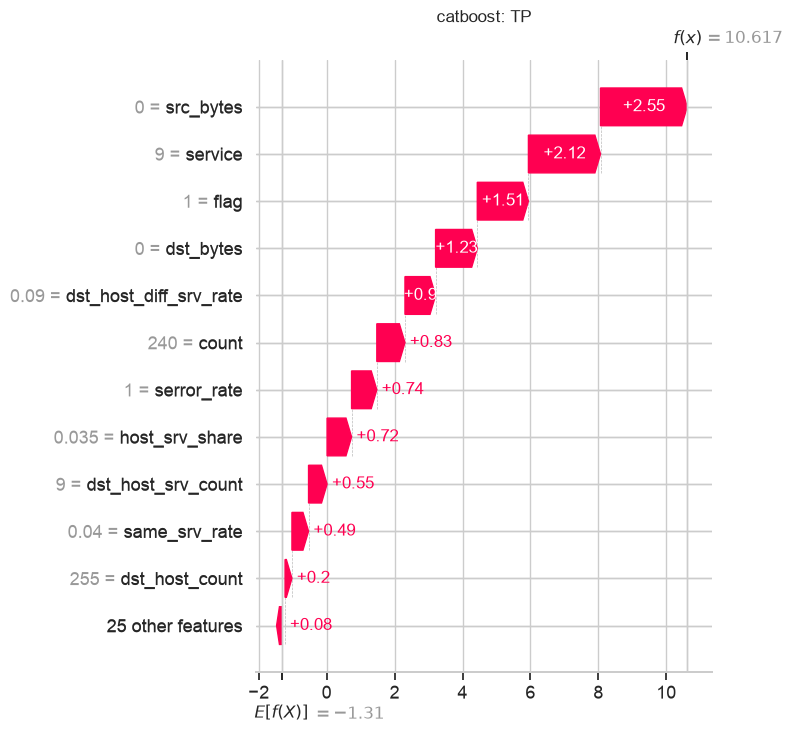

catboost TN true= 0 score= 5.218774391068175e-05 threshold= 0.25882705447098736


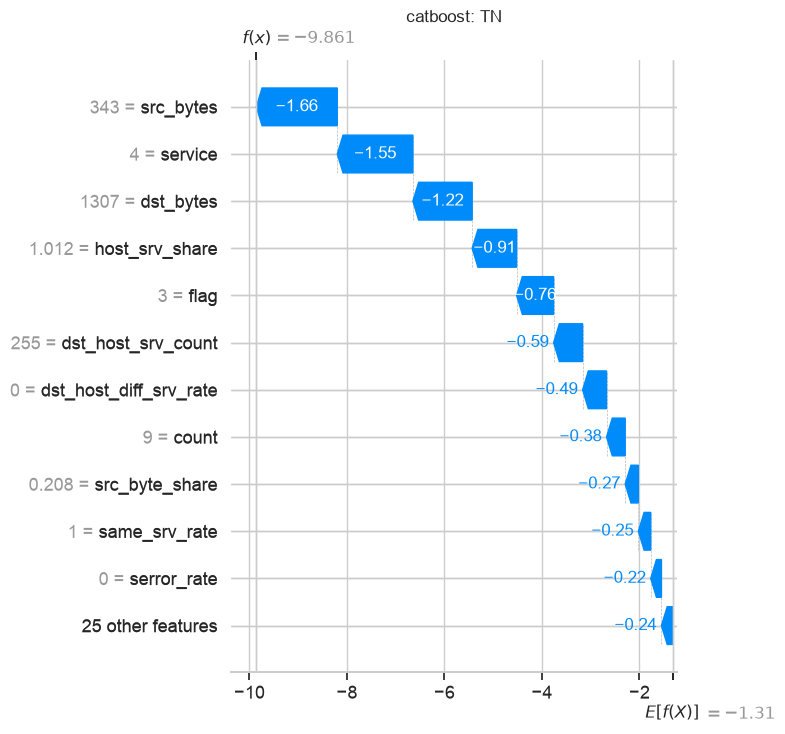

catboost FP true= 0 score= 0.6035297132267907 threshold= 0.25882705447098736


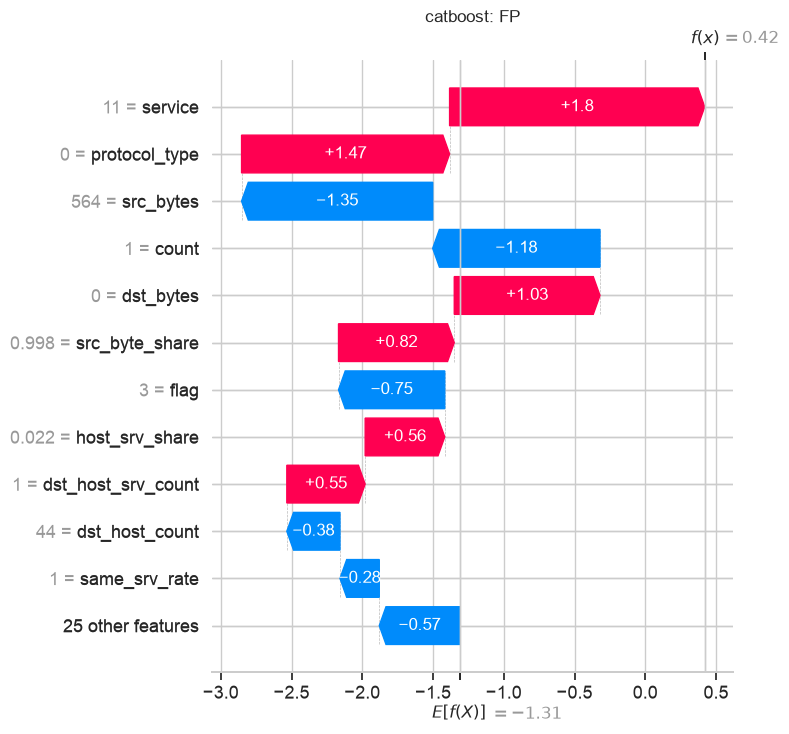

catboost FN true= 1 score= 0.009987925321982864 threshold= 0.25882705447098736


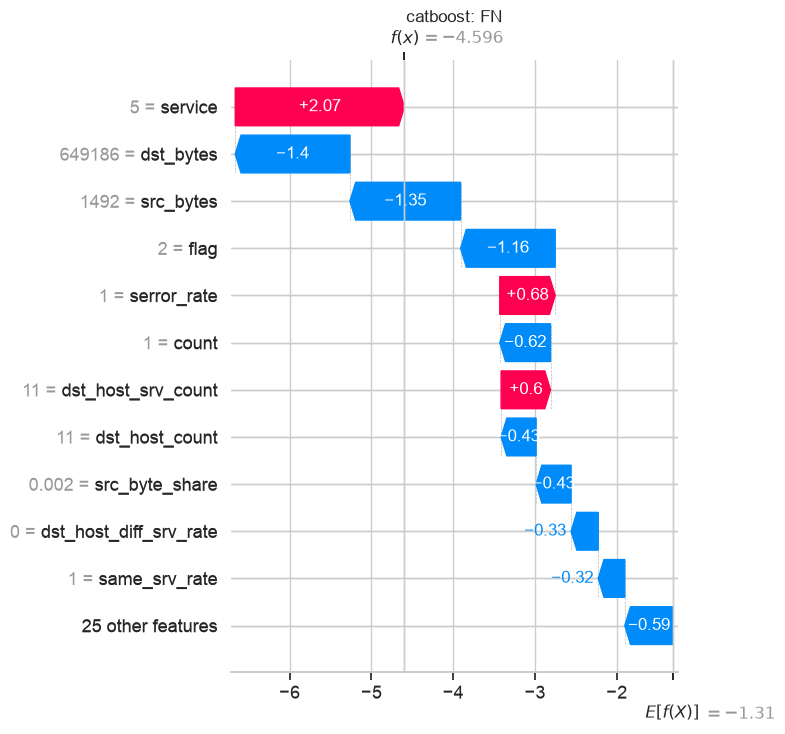

In [14]:
shap_importances = {}
for kind in KINDS:
    pipeline = pipelines[kind]
    pred = (scores[kind]["test"] >= thresholds[kind]).astype(int)
    representatives = {}
    for name, actual, predicted in [("TP", 1, 1), ("TN", 0, 0), ("FP", 0, 1), ("FN", 1, 0)]:
        available = np.flatnonzero((test_df.label.to_numpy() == actual) & (pred == predicted))
        if len(available):
            representatives[name] = int(available[0])
        else:
            print(f"{kind}: {name} отсутствуют при выбранном пороге")
    random_indices = test_df.sample(
        n=min(SHAP_ROWS, len(test_df)), random_state=SEED
    ).index.tolist()
    indices = list(
        dict.fromkeys(
            list(representatives.values())
            + test_df.sample(n=min(SHAP_ROWS, len(test_df)), random_state=SEED).index.tolist()
        )
    )
    explain_raw = test_df.loc[indices, RAW_FEATURES]
    transformed = pipeline[:-1].transform(explain_raw)
    model = pipeline.named_steps["model"]
    if kind == "catboost":
        native = model.get_feature_importance(
            Pool(transformed, cat_features=CATEGORICAL_FEATURES), type="ShapValues"
        )
        names = list(transformed.columns)
        display_data = transformed.copy()
        for col in CATEGORICAL_FEATURES:
            display_data[col] = pd.Categorical(display_data[col]).codes
        explanation = shap.Explanation(
            values=native[:, :-1],
            base_values=native[:, -1],
            data=display_data.to_numpy(),
            feature_names=names,
        )
        np.testing.assert_allclose(
            explanation.base_values + explanation.values.sum(axis=1),
            model.predict(transformed, prediction_type="RawFormulaVal"),
            atol=1e-6,
        )
    else:
        names = list(pipeline.named_steps["preprocessing"].get_feature_names_out())
        if kind == "logreg":
            background = pipeline[:-1].transform(
                X_train.sample(n=min(100, len(X_train)), random_state=SEED)
            )
            explanation = shap.LinearExplainer(model, background)(transformed)
            explanation.feature_names = names
            np.testing.assert_allclose(
                explanation.base_values + explanation.values.sum(axis=1),
                model.decision_function(transformed),
                atol=1e-6,
            )
        else:
            explanation = shap.TreeExplainer(model)(transformed, check_additivity=True)
            explanation.feature_names = names
            path_length = explanation.base_values + explanation.values.sum(axis=1)
            count = model.max_samples_
            normalizer = 2 * (np.log(count - 1) + np.euler_gamma) - 2 * (count - 1) / count
            recovered_score = 2 ** (-path_length / normalizer) + model.offset_
            np.testing.assert_allclose(recovered_score, scores[kind]["test"][indices], atol=1e-6)
    global_explanation = explanation[[indices.index(i) for i in random_indices]]
    shap.plots.bar(global_explanation, max_display=18, show=False)
    plt.title(f"{kind}: mean |SHAP|")
    plt.tight_layout()
    plt.show()
    shap.plots.beeswarm(global_explanation, max_display=18, show=False)
    plt.title(f"{kind}: SHAP distribution")
    plt.tight_layout()
    plt.show()
    importance = pd.DataFrame(
        {"feature": names, "mean_abs_shap": np.abs(global_explanation.values).mean(axis=0)}
    ).sort_values("mean_abs_shap", ascending=False)
    shap_importances[kind] = importance
    display(importance.head(20))
    for case, row_index in representatives.items():
        print(
            kind,
            case,
            "true=",
            int(test_df.loc[row_index, "label"]),
            "score=",
            float(scores[kind]["test"][row_index]),
            "threshold=",
            thresholds[kind],
        )
        shap.plots.waterfall(explanation[indices.index(row_index)], max_display=12, show=False)
        plt.title(f"{kind}: {case}")
        plt.tight_layout()
        plt.show()

## 14. Экспорт обученной модели и round-trip joblib
    Сохраняем **ту же модель**, для которой только что рассчитаны метрики, без повторного fit.
    Bundle: pipeline, kind, threshold, raw/selected features и metadata. Рядом — отчёт,
    bootstrap, CV, SHAP importance и журнал отбора. Проверяем равенство scores и predictions
    после загрузки. Артефакты `models/demo_*` требуют 41 KDD-признак и не заменяют live-модель
    `ids_iforest_v1`, чей Zeek-контракт содержит 16 признаков.

In [15]:
exported = {}
for kind in KINDS:
    artifact_dir = ROOT / f"models/demo_{kind}"
    report = {
        "metrics": reports[kind],
        "bootstrap_95_ci": confidence_intervals[kind].to_dict("records"),
        "cross_validation": cv_results[kind].to_dict("records"),
    }
    model_metadata = {
        "created_at_utc": datetime.now(UTC).isoformat(),
        "python": platform.python_version(),
        "versions": versions,
        "seed": SEED,
        "data_audit": audit,
        "split": "60/20/20 stratified unique feature vectors",
        "training": "normal train only" if kind == "iforest" else "all labeled train rows",
        "correlation_threshold": CORRELATION_THRESHOLD,
        "threshold_selection": "maximum validation F1 with FPR <= 0.05",
        "fit_seconds": training_times[kind],
        "live_compatible": False,
    }
    exported[kind] = export_bundle(
        artifact_dir,
        pipelines[kind],
        kind,
        thresholds[kind],
        report,
        model_metadata,
        shap_importances[kind],
        test_df[RAW_FEATURES].head(100),
    )
    print(kind, exported[kind], "round-trip OK")
display(metrics_table.loc[(slice(None), "test"), :].T)
print("Полный цикл выполнен. Test не использовался для обучения, отбора или выбора порога.")

logreg /Users/newuser/Documents/OTUS/2409/ids-ml-detection-lab/models/demo_logreg/model.joblib round-trip OK
catboost /Users/newuser/Documents/OTUS/2409/ids-ml-detection-lab/models/demo_catboost/model.joblib round-trip OK


model,logreg,catboost
split,test,test
roc_auc,0.998883,0.999962
average_precision,0.998640,0.999954
gini,0.997766,0.999925
accuracy,0.995638,0.999485
balanced_accuracy,0.995362,0.999425
precision,0.994974,0.999567
recall,0.994026,0.999134
f1,0.994500,0.999351
specificity,0.996698,0.999715


Полный цикл выполнен. Test не использовался для обучения, отбора или выбора порога.


## 15. Использование из командной строки и ограничения
    `uv run --all-groups python scripts/predict_demo.py --model models/demo_KIND/model.joblib --split test`
    загружает bundle и делает inference тем же интерпретатором. KIND: logreg, catboost.

    После изменения параметров заново выполните весь notebook; анализ test не должен становиться
    циклом подбора. Случайный split KDD не моделирует новые семейства атак и временной drift.
    Feature engineering по полному KDD недоступен в текущем live Zeek-контуре без расширения адаптера.
    Bootstrap предполагает независимые события и не даёт production-гарантий.